<div style="display: flex; background-color: RGB(35,115,127);" >
<h1 style="margin: auto; padding: 30px; color:#fff;">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<center>
<img src="../images/logo_societe.png" />
</center>


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

In [1]:
#Installation de calamine pour la lecture des fichiers xlsx
!pip install python-calamine

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [2]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la librairie numpy 
import numpy as np

#Importation de la librairie plotly express
import plotly.express as px

#Importation de la librairie plotly
import matplotlib.pyplot as plt

#Importation de la librairie Seaborn
import seaborn as sns


In [3]:
#Option permettant d'afficher toutes les colonnes du dataset
pd.set_option("display.max_columns",None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("Data_Bottleneck/web.xlsx", engine="calamine")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("Data_Bottleneck/erp.xlsx", engine="calamine")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("Data_Bottleneck/liaison.xlsx", engine="calamine")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le dataframe erp comporte {} lignes".format(df_erp.shape[0]))
print("Le dataframe erp comporte {} colonnes".format(df_erp.shape[1]))

Le dataframe erp comporte 825 lignes
Le dataframe erp comporte 6 colonnes


In [6]:
#Consulter le nombre de colonnes
print("Liste des colonnes du dataframe erp {}".format(list(df_erp.columns)))
print("-"*50)
#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe erp \n{}".format(df_erp.dtypes))
print("-"*50)
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_erp.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_erp.value_counts(column).reset_index())))


Liste des colonnes du dataframe erp ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price']
--------------------------------------------------
Nature des colonnes du dataframe erp 
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne product_id : 825
Nombre de valeurs présentes dans la colonne onsale_web : 2
Nombre de valeurs présentes dans la colonne price : 383
Nombre de valeurs présentes dans la colonne stock_quantity : 84
Nombre de valeurs présentes dans la colonne stock_status : 2
Nombre de valeurs présentes dans la colonne purchase_price : 660


In [7]:
#Afficher les 5 premières lignes de la table
print("5 premières lignes du dataset erp")
df_erp.head()


5 premières lignes du dataset erp


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.loc[df_erp["product_id"].duplicated(keep=False),:]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


<div>
<p style="margin: auto; padding: 20px; color: RGB(51,165,182);">
La colonne product_id du dataset erp ne contient pas de doublon
</p>
</div>


In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Valeurs de la colonne stock_status")
print(df_erp["stock_status"].value_counts())
print("-"*50)
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp_in_stock = df_erp[df_erp["stock_status"] == 'instock']
df_erp_out_of_stock = df_erp[df_erp["stock_status"] == 'outofstock']
print("Valeur de la colonne stock_quantity lorsque stock_status vaut instock")
print(df_erp_in_stock['stock_quantity'].value_counts())
print("Valeur de la colonne stock_quantity lorsque stock_status vaut outofstock")
print(df_erp_out_of_stock['stock_quantity'].value_counts())



Valeurs de la colonne stock_status
stock_status
instock       733
outofstock     92
Name: count, dtype: int64
--------------------------------------------------
Valeur de la colonne stock_quantity lorsque stock_status vaut instock
stock_quantity
7     32
23    30
12    29
5     27
29    22
      ..
74     1
71     1
86     1
91     1
55     1
Name: count, Length: 82, dtype: int64
Valeur de la colonne stock_quantity lorsque stock_status vaut outofstock
stock_quantity
 0     89
 3      1
-10     1
-1      1
Name: count, dtype: int64


<div>
<p style="margin: auto; padding: 20px; color: RGB(51,165,182);">
La colonne stock_status est liée à la colonne stock_quantity
</p>
</div>


In [10]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "instock" if x > 0 else "outofstock"
)

In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [12]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
somme_stock_status_stock_status_2_identique = (df_erp["stock_status"] == df_erp["stock_status_2"]).apply(
                                                    lambda x: 1 if x == True else 0
                                                ).sum()
print("{} valeurs sont identiques pour les colonnes stock_status et stock_status_2".format(somme_stock_status_stock_status_2_identique))
print("{} valeurs sont différentes pour les colonnes stock_status et stock_status_2".
      format(df_erp.shape[0] - somme_stock_status_stock_status_2_identique))


823 valeurs sont identiques pour les colonnes stock_status et stock_status_2
2 valeurs sont différentes pour les colonnes stock_status et stock_status_2


In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

print("Lignes du dataset erp ayant les colonnes stock_status et stock_status_2 différentes")
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

Lignes du dataset erp ayant les colonnes stock_status et stock_status_2 différentes


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [14]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"], 'stock_status'] = df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"], 'stock_status_2']

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
somme_stock_status_stock_status_2_identique = (df_erp["stock_status"] == df_erp["stock_status_2"]).apply(
                                                    lambda x: 1 if x == True else 0
                                                ).sum()
print("{} valeurs sont identiques pour les colonnes stock_status et stock_status_2".format(somme_stock_status_stock_status_2_identique))
print("{} valeurs sont différentes pour les colonnes stock_status et stock_status_2".
      format(df_erp.shape[0] - somme_stock_status_stock_status_2_identique))


825 valeurs sont identiques pour les colonnes stock_status et stock_status_2
0 valeurs sont différentes pour les colonnes stock_status et stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum()))

#Afficher le prix minimum de la colonne "price"
print("Prix minimum de la colonne price: {} €".format(df_erp['price'].min()))

#Afficher le prix maximum de la colonne "price"
print("Prix maximum de la colonne price: {} €".format(df_erp['price'].max()))

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Prix inférieur à 0 €")
df_erp[df_erp['price'] < 0]


Nombres d'articles avec un prix non renseigné: 0
Prix minimum de la colonne price: -20.0 €
Prix maximum de la colonne price: 225.0 €
Prix inférieur à 0 €


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


<div>
<p style="margin: auto; padding: 20px; color: RGB(51,165,182);">
Il y a 3 prix négatifs on ne peut pas vendre les produits à perte on regardera ulterieurement le taux de marge de ces produits et on verra si on les garde
</p>
</div>


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [16]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Prix minimum de la colonne stock_quantity: {}".format(df_erp['stock_quantity'].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Prix minimum de la colonne stock_quantity: {}".format(df_erp['stock_quantity'].max()))

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Stocks inférieurs à 0")
df_erp[df_erp['stock_quantity'] < 0]

Prix minimum de la colonne stock_quantity: -10
Prix minimum de la colonne stock_quantity: 145
Stocks inférieurs à 0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


<div>
<p style="margin: auto; padding: 20px; color: RGB(51,165,182);">
Il y a 2 produits en stocks qui sont négatifs.
On garde ces lignes car il peut s'agir de produit commandé qui sont en rupture de stock
</p>
</div>


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [17]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp["onsale_web"].value_counts()


onsale_web
1    716
0    109
Name: count, dtype: int64

<div>
<p style="margin: auto; padding: 20px; color: RGB(51,165,182);">
La colonne <b>onsale_web</b> vaut 1 si le produit est vendu sur le web et 0 sinon.
</p>
</div>


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les colonnes suivantes sont conservées
</p>
<ul style="margin: auto; padding: 20px; color: RGB(51,165,182);">
<li>
    <b>product_id</b> pour avoir l'identifiant du produit
</li>
<li>
    <b>onsale_web</b> pour savoir si le produit est vendu sur le web
</li>
<li>
    <b>price</b> pour connaitre le prix de vente du produit
</li>
<li>
    <b>stock_quantity</b> pour connaitre les quantité de stock
</li>
<li>
    <b>purchase_price</b> est la prix d'achat et ne donne pas de renseignement sur les ventes
</li>
</ul>
</div>

In [18]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns=["stock_status_2", "stock_status"], inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [19]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix d'achat non renseigné: {}".format(df_erp['purchase_price'].isnull().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum de la colonne purchase_price: {} €".format(df_erp['purchase_price'].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum de la colonne purchase_price: {} €".format(df_erp['purchase_price'].max()))

Nombres d'articles avec un prix d'achat non renseigné: 0
Prix minimum de la colonne purchase_price: 2.74 €
Prix maximum de la colonne purchase_price: 137.81 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [20]:
#Dimension du dataset
#Nombre d'observations
print("Le dataframe web comporte {} lignes".format(df_web.shape[0]))

#Nombre de caractéristiques
print("Le dataframe web comporte {} colonnes".format(df_web.shape[1]))

Le dataframe web comporte 1513 lignes
Le dataframe web comporte 29 colonnes


In [21]:
#Consulter le nombre de colonnes
print("Liste des colonnes du dataframe web \n{}".format(list(df_web.columns)))
print("-"*50)

#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe web \n{}".format(df_web.dtypes))
print("-"*50)

#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_web.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_web.value_counts(column).reset_index())))


Liste des colonnes du dataframe web 
['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating', 'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date', 'post_date_gmt', 'post_content', 'product_type', 'post_title', 'post_excerpt', 'post_status', 'comment_status', 'ping_status', 'post_password', 'post_name', 'post_modified', 'post_modified_gmt', 'post_content_filtered', 'post_parent', 'guid', 'menu_order', 'post_type', 'post_mime_type', 'comment_count']
--------------------------------------------------
Nature des colonnes du dataframe web 
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datet

In [22]:
print("Affichage des 5 premières lignes du dataframe web")
df_web.head()

Affichage des 5 premières lignes du dataframe web


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
On conserve les colonnes suivantes: <b>sku</b>, <b>total_sales</b>, <b>tax_status</b>, <b>product_type</b> et <b>post_title</b>
</p>
</div>

In [23]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web_ventes = df_web[["sku","total_sales","tax_status", "product_type", "post_title"]]

print("Affichage des 5 premières lignes du dataframe web")
df_web_ventes.head()

Affichage des 5 premières lignes du dataframe web


,sku,total_sales,tax_status,product_type,post_title
0,11862,3.0,NaN,Vin,Gilles Robin Hermitage Rouge 2012
1,16057,5.0,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016
3,16295,14.0,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017


In [24]:
#Visualisation des valeurs de la colonne sku
print("Valeurs de la colonne SKU")
display(df_web_ventes['sku'].values)

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?

#Liste des sku qui ne sont pas des int et qui sont non null
list_sku_string = []
print("Liste des sku qui ne sont pas entiers et qui ne sont pas null")
for sku in df_web_ventes[df_web_ventes['sku'].notnull()]['sku'].values:
    if not isinstance(sku, int):
        list_sku_string.append(sku)

display(list_sku_string)

Valeurs de la colonne SKU


array([11862, 16057, 14692, ..., 15329, 14827, 16004], dtype=object)

Liste des sku qui ne sont pas entiers et qui ne sont pas null


['13127-1', 'bon-cadeau-25-euros', '13127-1', 'bon-cadeau-25-euros']

In [25]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
print("Liste des sku qui ne sont pas des entiers et qui ne sont pas null")
df_web_ventes[df_web_ventes['sku'].isin(list_sku_string)]


Liste des sku qui ne sont pas des entiers et qui ne sont pas null


,sku,total_sales,tax_status,product_type,post_title
272,13127-1,4.0,taxable,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
842,bon-cadeau-25-euros,7.0,NaN,Autre,Bon cadeau de 25€
1117,13127-1,4.0,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387,bon-cadeau-25-euros,7.0,taxable,NaN,Bon cadeau de 25€


In [26]:
#Identifier les lignes sans code article
print("Il y a {} du dataframe web qui n'ont pas de sku".format(df_web_ventes['sku'].isnull().sum()))
print("Lignes du dataframe web qui n'ont pas de sku")
df_web_ventes_sans_sku = df_web_ventes[df_web_ventes['sku'].isnull()]
df_web_ventes_sans_sku.iloc[60:70,:]

Il y a 85 du dataframe web qui n'ont pas de sku
Lignes du dataframe web qui n'ont pas de sku


,sku,total_sales,tax_status,product_type,post_title
987,NaN,NaN,NaN,NaN,NaN
1005,NaN,NaN,NaN,NaN,NaN
1018,NaN,NaN,NaN,NaN,NaN
1045,NaN,NaN,NaN,NaN,NaN
1065,NaN,NaN,NaN,NaN,NaN
1084,NaN,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018
1086,NaN,NaN,NaN,NaN,NaN
1087,NaN,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017
1098,NaN,NaN,NaN,NaN,NaN
1135,NaN,NaN,NaN,NaN,NaN


In [27]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print("Valeur vide parmi les ligne qui ont un SKU vide")
print(df_web_ventes_sans_sku.isnull().sum())

print("2 valeurs de la colonne total_sales renseignées et 2 valeurs de la colonne product_type sont renseignées " \
"dans le dataframe web ayant des skus non renseignés")

print("Colonnes autre que SKU qui sont non nulles lorsque le SKU est nul")
df_web_ventes_sans_sku[df_web_ventes_sans_sku['total_sales'].notnull()]


Valeur vide parmi les ligne qui ont un SKU vide
sku             85
total_sales     83
tax_status      83
product_type    83
post_title      83
dtype: int64
2 valeurs de la colonne total_sales renseignées et 2 valeurs de la colonne product_type sont renseignées dans le dataframe web ayant des skus non renseignés
Colonnes autre que SKU qui sont non nulles lorsque le SKU est nul


,sku,total_sales,tax_status,product_type,post_title
1084,NaN,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018
1087,NaN,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Dans le dataframe web, <b>85</b> lignes ont un sku non renseigné, parmi les lignes qui sont un sku non renseigné seule 2 lignes sont remplies
</p>
</div>

In [28]:
#Suppression des SKU vide
df_web_ventes = df_web_ventes.dropna(subset={"sku"})

print("85 lignes ont été supprimées du dataframe web il reste {} lignes".format(df_web_ventes.shape[0]))

df_web_ventes.head()

85 lignes ont été supprimées du dataframe web il reste 1428 lignes


,sku,total_sales,tax_status,product_type,post_title
0,11862,3.0,NaN,Vin,Gilles Robin Hermitage Rouge 2012
1,16057,5.0,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016
3,16295,14.0,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017


In [29]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print("Nombre de SKU en doublon {}".format(len(df_web_ventes.loc[df_web_ventes["sku"].duplicated(keep=False),:])))

#Affichage de nombre d'apparition d'un sku dans le fichier
print("Nombre d'apparition d'un sku dans le fichier")
print(df_web_ventes["sku"].value_counts().reset_index()["count"].value_counts())

#Affichage de 10 skus qui sont en doublon dans le dataframe web
print("Affichage de 10 skus qui sont en doublon dans le dataframe web")
df_web_ventes_sku_duplicate = df_web_ventes.loc[df_web_ventes["sku"].duplicated(keep=False),:]
df_web_ventes_sku_duplicate[~df_web_ventes_sku_duplicate.isin(list_sku_string)].sort_values(by="sku").head(10)


Nombre de SKU en doublon 1428
Nombre d'apparition d'un sku dans le fichier
count
2    714
Name: count, dtype: int64
Affichage de 10 skus qui sont en doublon dans le dataframe web


,sku,total_sales,tax_status,product_type,post_title
964,38,10.0,taxable,Vin,Emile Boeckel Crémant Brut Blanc de Blancs
458,38,10.0,NaN,Vin,Emile Boeckel Crémant Brut Blanc de Blancs
965,41,6.0,taxable,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...
1127,41,6.0,NaN,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...
1210,304,8.0,taxable,Champagne,Champagne Gosset Grande Réserve
297,304,8.0,NaN,Champagne,Champagne Gosset Grande Réserve
1430,523,0.0,NaN,Cognac,Cognac Normandin Mercier VFC
899,523,0.0,taxable,Cognac,Cognac Normandin Mercier VFC
501,531,8.0,NaN,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...
1442,531,8.0,taxable,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...


In [30]:
print("Nombre de SKU et total_sales en doublon {}".format(len(df_web_ventes.loc[df_web_ventes[["sku", "total_sales", "product_type"]].duplicated(keep=False),:])))

#Affichage de nombre d'apparition d'un sku et du total vente dans le fichier
df_nb_apparition_sku_total_sales = df_web_ventes[["sku", "total_sales", "product_type"]].value_counts().reset_index()

print("Nombre d'apparition d'un couple sku total_sales dans le fichier")
print(df_nb_apparition_sku_total_sales["count"].value_counts())


Nombre de SKU et total_sales en doublon 1418
Nombre d'apparition d'un couple sku total_sales dans le fichier
count
2    709
1      9
Name: count, dtype: int64


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Toutes les valeurs de SKU sont en doublons dans le dataframe web
</p>
</div>

In [31]:
#Suppression des couples sku et total_sales qui sont en doublon, on garde la ligne dont la colonne tax_status vatu taxbale
df_web_ventes = df_web_ventes.sort_values(by=["sku", "tax_status"]).drop_duplicates(subset=["sku","total_sales"], keep="first")

#Affichage des sku qui sont en doublon
print("Affichage des SKU qui sont en doublon après suppression des couples sku et total_sales qui étaient en doublon")
display(df_web_ventes.loc[df_web_ventes[["sku"]].duplicated(keep=False),:].sort_values(by='sku'))

Affichage des SKU qui sont en doublon après suppression des couples sku et total_sales qui étaient en doublon


,sku,total_sales,tax_status,product_type,post_title
548,1366,6.0,taxable,Champagne,Champagne Mailly Grand Cru Intemporelle 2010
523,1366,116.0,NaN,Champagne,Champagne Mailly Grand Cru Intemporelle 2010
1052,14561,11.0,taxable,Vin,Argentine Mendoza Alamos Torrontes 2017
114,14561,111.0,NaN,Vin,Argentine Mendoza Alamos Torrontes 2017
999,14950,22.0,taxable,Vin,François Baur Pinot Noir Schlittweg 2017
452,14950,122.0,NaN,Vin,François Baur Pinot Noir Schlittweg 2017
843,15346,2.0,taxable,Vin,Albert Mann Pinot Noir Grand H 2017
219,15346,22.0,NaN,Vin,Albert Mann Pinot Noir Grand H 2017


In [32]:
#Suppression des lignes dont le sku est dupliqué et qui ont un champ tax_status non renseigné
df_web_ventes = df_web_ventes.sort_values(by=["sku", "tax_status"]).drop_duplicates(subset=["sku"], keep="first")

#Affichage des sku en doublons
print("Affichage des SKU en doublon")
display(df_web_ventes.loc[df_web_ventes[["sku"]].duplicated(keep=False),:])




Affichage des SKU en doublon


,sku,total_sales,tax_status,product_type,post_title


In [33]:
print("Le dataframe des web nettoyé contient {} lignes".format(df_web_ventes.shape[0]))

Le dataframe des web nettoyé contient 714 lignes


In [34]:
#Suppression de la colonne tax_status
df_web_ventes.drop(labels="tax_status", inplace=True, axis=1)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [35]:
#Dimension du dataset
#Nombre d'observations
print("Le dataframe liaison comporte {} lignes".format(df_liaison.shape[0]))

#Nombre de caractéristiques
print("Le dataframe liaison comporte {} colonnes".format(df_liaison.shape[1]))

Le dataframe liaison comporte 825 lignes
Le dataframe liaison comporte 2 colonnes


In [36]:
#Consulter le nombre de colonnes
print("Liste des colonnes du dataframe liaison {}".format(list(df_liaison.columns)))
print("-"*50)
      
#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe liaison \n{}".format(df_liaison.dtypes))
print("-"*50)

#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_liaison.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_liaison.value_counts(column).reset_index())))


Liste des colonnes du dataframe liaison ['id_web', 'product_id']
--------------------------------------------------
Nature des colonnes du dataframe liaison 
id_web        object
product_id     int64
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne id_web : 734
Nombre de valeurs présentes dans la colonne product_id : 825


In [37]:
#5 première ligne du dataframe laisain
print("5 premières lignes du dataframe liaison")
df_liaison.head()

5 premières lignes du dataframe liaison


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [38]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
display(df_liaison.loc[df_liaison["product_id"].duplicated(keep=False),:])

,id_web,product_id


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les valeurs de la colonnes <b> product_id</b> sont uniques
</p>
</div>

In [39]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Recherche des valeurs de la colonne id_web qui sont en double")
display(df_liaison.loc[df_liaison["id_web"].duplicated(keep=False),:].head())

#Recherche des valeurs de la colonne id_web qui ne sont pas en double
print("Recherche des valeurs de la colonne id_web qui sont en double et qui ne sont pas nulles")
df_liaison_id_web_not_null = df_liaison[df_liaison["id_web"].notnull()]
display(df_liaison_id_web_not_null.loc[df_liaison_id_web_not_null["id_web"].duplicated(keep=False),:])

Recherche des valeurs de la colonne id_web qui sont en double


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


Recherche des valeurs de la colonne id_web qui sont en double et qui ne sont pas nulles


,id_web,product_id


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les valeurs de la colonnes <b> id_web</b> sont uniques
</p>
</div>

In [40]:
#Liste des id_web qui ne sont pas des int et qui sont non null
list_id_web_string = []
print("Liste des id_web qui ne sont pas entiers et qui ne sont pas null")
for id_web in df_liaison_id_web_not_null['id_web'].values:
    if not isinstance(id_web, int):
        list_id_web_string.append(id_web)

display(list_id_web_string)
df_liaison_id_web_not_null[df_liaison_id_web_not_null["id_web"].isin(list_id_web_string)]

Liste des id_web qui ne sont pas entiers et qui ne sont pas null


['bon-cadeau-25-euros', '13127-1', '14680-1']

,id_web,product_id
443,bon-cadeau-25-euros,4954
822,13127-1,7247
823,14680-1,7329


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
La colonne <b> id_web</b> contient des valeurs numériques et des chaînes de caractère
</p>
</div>

In [41]:
#Avons-nous des articles sans correspondance?
print("Articles qui n'ont pas de références dans le web")
display(df_liaison[(df_liaison["product_id"].notnull()) & (df_liaison["id_web"].isnull())].head(10))

print("{} articles sur {} ont des références web".format(df_liaison[df_liaison["id_web"].notnull()].shape[0], df_liaison.shape[0]))

Articles qui n'ont pas de références dans le web


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
151,NaN,4233
184,NaN,4278
185,NaN,4279
234,NaN,4565
238,NaN,4577


734 articles sur 825 ont des références web


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les articles qui n'ont pas d'id_web sont des articles qui ne sont pas vendus sur le web
</p>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [42]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(left=df_liaison, right=df_erp, on="product_id", how="left", validate="one_to_one")

print("Le merge des dataframe erp et liaison possède {} lignes".format(df_erp_liaison.shape[0]))


Le merge des dataframe erp et liaison possède 825 lignes


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les dataframes erp et liaison ont chacun 825 lignes et le merge de ces 2 dataframes possède aussi 825 lignes donc toutes les lignes de ces dataframe matchent
</p>
</div>

In [43]:
#Vérification  que la colonne onsale_web est à 1 lorsque la colonne id_web n'est pas

df_erp_liaison["onsale_web_2"] = df_erp_liaison["id_web"].apply(
    lambda x: 1 if isinstance(x, (int, str)) else 0
)

df_erp_liaison[df_erp_liaison["onsale_web"] != df_erp_liaison["onsale_web_2"]]

,id_web,product_id,onsale_web,price,stock_quantity,purchase_price,onsale_web_2
123,16295,4200,0,5.8,33,3.12,1
193,13771,4289,0,22.8,0,11.90,1
236,15065,4568,0,21.5,0,11.22,1
241,14785,4584,0,32.3,0,17.36,1
242,NaN,4594,1,144.0,0,87.36,0
355,12601,4741,0,12.4,0,6.66,1
391,15154,4864,0,8.3,0,9.99,1
394,14360,4869,0,17.2,0,9.33,1
424,15608,4921,0,13.8,0,7.13,1
425,15586,4922,0,21.5,0,10.55,1


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
La colonne <b>onsale_web</b> n'est pas correctemen renseignée pour 24 lignes
</p>
</div>

In [44]:
print("Affichage des prix négatifs")
df_erp_liaison[df_erp_liaison["price"] < 0]

Affichage des prix négatifs


,id_web,product_id,onsale_web,price,stock_quantity,purchase_price,onsale_web_2
151,NaN,4233,0,-20.0,0,10.33,0
469,NaN,5017,0,-8.0,0,4.34,0
739,NaN,6594,0,-9.1,19,4.61,0


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les articles ayant des prix négatifs n'ont pas d'identifiant web
</p>
</div>

In [45]:
#Suppression des lignes qui ont le champ id_web non renseigné
df_erp_liaison = df_erp_liaison[df_erp_liaison["id_web"].notnull()]

#Suppression des colonnes onsale_web et onsale_web_2
df_erp_liaison.drop(columns=["onsale_web", "onsale_web_2"], inplace=True)

print("La dataset de résultant du merge du fichier des erp et de laison possède {} lignes".format(df_erp_liaison.shape[0]))

La dataset de résultant du merge du fichier des erp et de laison possède 734 lignes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [46]:
#Fusionner les datasets df_merge et df_web
df_erp_liaison_web = pd.merge(left=df_web_ventes, right=df_erp_liaison, left_on="sku", right_on="id_web", how="left")

#Suppression de la colonne sku qui a la même valeur que la colonne id_web
df_erp_liaison_web.drop(columns="sku", inplace=True)

#Suppression de la colonne product_id car on a déjà l'identifiant web
df_erp_liaison_web.drop(columns="product_id", inplace=True)

#Réorganisation de colonne
df_erp_liaison_web = df_erp_liaison_web[["id_web","product_type","total_sales","price","purchase_price","stock_quantity", "post_title"]]

print("Affichage des 5 premières lignes du dataset mergé")
display(df_erp_liaison_web.head())


Affichage des 5 premières lignes du dataset mergé


,id_web,product_type,total_sales,price,purchase_price,stock_quantity,post_title
0,38,Vin,10.0,8.6,4.22,26,Emile Boeckel Crémant Brut Blanc de Blancs
1,41,Vin,6.0,41.0,20.12,11,Marcel Windholtz Eau de Vie de Marc de Gewurzt...
2,304,Champagne,8.0,39.0,24.86,123,Champagne Gosset Grande Réserve
3,523,Cognac,0.0,59.9,27.18,13,Cognac Normandin Mercier VFC
4,531,Champagne,8.0,22.5,13.78,76,Champagne Petit Lebrun &amp; Fils Blanc de Bla...


In [47]:
#Avons-nous des lignes sans correspondance?
print("Le dataset mergé possède {} lignes".format(df_erp_liaison_web.shape[0]))
print("Le dataset des ventes web possède {} lignes".format(df_web_ventes.shape[0]))


Le dataset mergé possède 714 lignes
Le dataset des ventes web possède 714 lignes


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Il n'y a pas de ligne sans correspondance
</p>
</div>

In [48]:
#Harmonisation des idenfiant web

#Recherche de l'identifiant web entier qui est le plus élevé
max_id_web = df_erp_liaison_web[~df_erp_liaison_web['id_web'].isin(list_sku_string)]["id_web"].max()

#Remplacement des identifiant web qui sont des string par un entier
for sku_string in list_sku_string :
    df_erp_liaison_web.loc[df_erp_liaison_web['id_web'] == sku_string, "id_web"] = max_id_web + 1
    max_id_web = max_id_web + 1


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

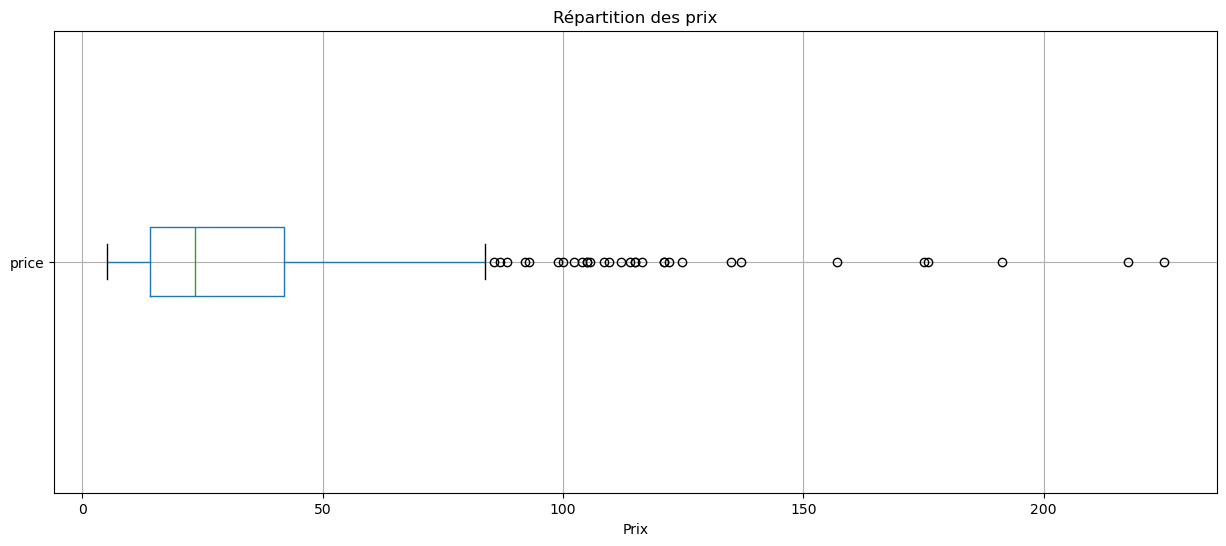

In [49]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
plt.figure(figsize=(15, 6))
df_erp_liaison_web.boxplot(column="price", vert=False)
plt.title("Répartition des prix")
plt.xlabel("Prix")
plt.show()

In [50]:
#Autre méthode avec plotly express
fig = px.box(data_frame = df_erp_liaison_web, x="price", title="Répartition des prix", labels={"price":"prix"})
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D'
)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [51]:
#Calculer la moyenne du prix
moyenne_prix = df_erp_liaison_web["price"].mean()
print("Moyenne du prix {:.2f} €".format(moyenne_prix))

#Calculer l'écart-type du prix
ecart_type_prix = df_erp_liaison_web["price"].std()
print("Ecart type du prix {:.2f} €".format(ecart_type_prix))

#Calculer le Z-score

df_product_price = df_erp_liaison_web[['price']].copy()
df_product_price["zscore_price"] = (df_product_price['price'] - moyenne_prix) / ecart_type_prix

print("5 premières lignes contenant lezscore du prix")
df_product_price.head()


Moyenne du prix 32.33 €
Ecart type du prix 27.60 €
5 premières lignes contenant lezscore du prix


,price,zscore_price
0,8.6,-0.860030
1,41.0,0.314039
2,39.0,0.241565
3,59.9,0.998912
4,22.5,-0.356340


In [52]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
print("Seuil de prix dont le z-score est supérieur à 3")
df_product_price[df_product_price["zscore_price"] > 3].sort_values(by="zscore_price")


Seuil de prix dont le z-score est supérieur à 3


,price,zscore_price
279,116.4,3.046286
269,121.0,3.212975
270,121.0,3.212975
225,122.0,3.249211
245,124.8,3.350674
246,135.0,3.720288
168,137.0,3.792762
33,157.0,4.517496
300,175.0,5.169756
24,176.0,5.205993


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Le seuil de prix dont le z-score est supétieur à 3 est <b>116,4</b>
</p>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [53]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
print("Mesures de dispersion de la colonne price")
df_erp_liaison_web["price"].describe()


Mesures de dispersion de la colonne price


count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [54]:
#Définir un seuil pour les articles "outliers" en prix

#Récupération des valeurs Q1 et Q3
q1_price = df_erp_liaison_web["price"].describe().iloc[4]
q3_price = df_erp_liaison_web["price"].describe().iloc[6]

print("Le premier quartile du prix est {:.2f}".format(q1_price))
print("Le troisième  quartile du prix est {:.2f}".format(q3_price))

#Calcul des seuils
seuil_bas_price = q1_price - 1.5 * (q3_price - q1_price)
seuil_haut_price = q3_price + 1.5 * (q3_price - q1_price)

print("Le seuil bas du prix est {:.2f}".format(seuil_bas_price))
print("Le seuil haut du prix est {:.2f}".format(seuil_haut_price))

Le premier quartile du prix est 14.06
Le troisième  quartile du prix est 42.08
Le seuil bas du prix est -27.96
Le seuil haut du prix est 84.09


In [55]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_article_prix_outliner = df_erp_liaison_web[(df_erp_liaison_web["price"] < seuil_bas_price) | (df_erp_liaison_web["price"] > seuil_haut_price)].sort_values(by="price")
nb_article_outliers = len(df_article_prix_outliner)
nb_article_total = len(df_erp_liaison_web)
print("Le nombre d'article en outiers est de {}".format(nb_article_outliers))
print("Ce qui représente {:.2%} de l'ensemble du catalogue".format(nb_article_outliers / nb_article_total))

Le nombre d'article en outiers est de 31
Ce qui représente 4.34% de l'ensemble du catalogue


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Ces outliers peuvent être justifiés, ce sont peut-être des bouteilles de vin qui coûtent très cher.
</p>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [56]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_erp_liaison_web["CA"] = df_erp_liaison_web["total_sales"] * df_erp_liaison_web["price"]
print("Vente avec CA par article")
display(df_erp_liaison_web.head())

#Calculer la somme de la colonne "ca_par_article"
chiffre_affaire_site_web = df_erp_liaison_web["CA"].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print("Le chiffre d'affaire du site web est de {} €".format(chiffre_affaire_site_web))

Vente avec CA par article


,id_web,product_type,total_sales,price,purchase_price,stock_quantity,post_title,CA
0,38,Vin,10.0,8.6,4.22,26,Emile Boeckel Crémant Brut Blanc de Blancs,86.0
1,41,Vin,6.0,41.0,20.12,11,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,246.0
2,304,Champagne,8.0,39.0,24.86,123,Champagne Gosset Grande Réserve,312.0
3,523,Cognac,0.0,59.9,27.18,13,Cognac Normandin Mercier VFC,0.0
4,531,Champagne,8.0,22.5,13.78,76,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,180.0


Le chiffre d'affaire du site web est de 143680.1 €


In [57]:
print("Statistiques descritives du chiffre d'affaire")
df_erp_liaison_web["CA"].describe()

Statistiques descritives du chiffre d'affaire


count     714.000000
mean      201.232633
std       153.761401
min         0.000000
25%       122.025000
50%       168.000000
75%       240.400000
max      2475.000000
Name: CA, dtype: float64

In [58]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_erp_liaison_web = df_erp_liaison_web.sort_values(by="CA", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_erp_liaison_web = df_erp_liaison_web.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
print("20 premiers articles en CA")
df_erp_liaison_web_20_best_CA = df_erp_liaison_web[["id_web", "price","total_sales","CA", "post_title"]].head(20)
display(df_erp_liaison_web_20_best_CA)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(data_frame = df_erp_liaison_web_20_best_CA, x="post_title", y="CA", title="Articles ayant le chiffre d'affaire le plus élevé", labels={"CA":"Chiffre d'affaire","post_title":"Bouteille"})
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D',
    height=800
)
fig.show()


20 premiers articles en CA


,id_web,price,total_sales,CA,post_title
0,15940,225.0,11.0,2475.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008
1,14983,191.3,6.0,1147.8,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...
2,12587,79.5,14.0,1113.0,Champagne Egly-Ouriet Grand Cru Brut Rosé
3,15325,41.2,20.0,824.0,Agnès Levet Côte Rôtie Améthyste 2017
4,13996,115.0,7.0,805.0,Domaine des Comtes Lafon Volnay 1er Cru Santen...
5,13913,86.8,9.0,781.2,Champagne Agrapart &amp; Fils Minéral Extra Br...
6,11602,105.0,7.0,735.0,Domaine des Comtes Lafon Volnay 1er Cru Santen...
7,15185,175.0,4.0,700.0,Camille Giroud Clos de Vougeot 2016
8,14923,135.0,5.0,675.0,Champagne Gosset Célébris Vintage 2007
9,13914,112.0,6.0,672.0,Champagne Agrapart &amp; Fils L'Avizoise Extra...


In [59]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_erp_liaison_web["part_CA"] = df_erp_liaison_web["CA"] / chiffre_affaire_site_web

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_liaison_web["cumul_part_CA"] = np.cumsum(df_erp_liaison_web["part_CA"])

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_article_representant_80_CA = len(df_erp_liaison_web[df_erp_liaison_web["cumul_part_CA"] <= 0.8])
print("{} articles représentent 80% du chiffre d'affaire".format(nb_article_representant_80_CA))

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{:.2%} des articles représentent 80% du chiffre d'affaire".format(nb_article_representant_80_CA / df_erp_liaison_web.shape[0]))


434 articles représentent 80% du chiffre d'affaire
60.78% des articles représentent 80% du chiffre d'affaire


In [60]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 20% du CA
nb_article_representant_20_CA = len(df_erp_liaison_web[df_erp_liaison_web["cumul_part_CA"] <= 0.2])
print("{} articles représentent 20% du chiffre d'affaire".format(nb_article_representant_20_CA))

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{:.2%} des articles représentent 20% du chiffre d'affaire".format(nb_article_representant_20_CA / df_erp_liaison_web.shape[0]))

49 articles représentent 20% du chiffre d'affaire
6.86% des articles représentent 20% du chiffre d'affaire


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [61]:
print("Statistiques descriptive des quantités vendus")
df_erp_liaison_web["total_sales"].describe()

Statistiques descriptive des quantités vendus


count    714.000000
mean       8.054622
std        4.161344
min        0.000000
25%        5.000000
50%        8.000000
75%       11.000000
max       36.000000
Name: total_sales, dtype: float64

In [62]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_erp_liaison_web = df_erp_liaison_web.sort_values(by="total_sales", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_erp_liaison_web = df_erp_liaison_web.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
print("20 premiers article en quantité vendue")
df_erp_liaison_web_20_top_sales_quantity = df_erp_liaison_web[["id_web", "total_sales", "post_title"]].head(20)
display(df_erp_liaison_web_20_top_sales_quantity)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(data_frame = df_erp_liaison_web_20_top_sales_quantity, x="post_title", y="total_sales", title="20 articles ayant la quantité vendue la plus élevée", labels={"total_sales":"Quantité","post_title":"Bouteille"})
fig.update_xaxes(type = "category")
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D',
    height= 800
)
fig.show()


20 premiers article en quantité vendue


,id_web,total_sales,post_title
0,16148,36.0,Château De La Selve IGP Coteaux de l'Ardèche M...
1,15415,27.0,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...
2,14864,24.0,I Fabbri Chianti Classico Lamole 2017
3,14950,22.0,François Baur Pinot Noir Schlittweg 2017
4,16525,22.0,Bernard Baudry Chinon Rouge La Croix Boissée 2017
5,15325,20.0,Agnès Levet Côte Rôtie Améthyste 2017
6,14570,20.0,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...
7,15758,18.0,Xavier Frissant Touraine Amboise Chenin Les Pi...
8,15705,17.0,Decelle-Villa Chorey-Lès-Beaune 2016
9,15561,17.0,Maurel Pays d'Oc Merlot 2018


In [63]:
###################################
# Calculer le 20 / 80 en quantité #
###################################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_quantity_sales = df_erp_liaison_web["total_sales"].sum()
df_erp_liaison_web["part_total_sales"] = df_erp_liaison_web["total_sales"] / total_quantity_sales

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_erp_liaison_web["cumul_part_total_sales"] = np.cumsum(df_erp_liaison_web["part_total_sales"])

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_article_representant_80_quantity_sales = len(df_erp_liaison_web[df_erp_liaison_web["cumul_part_total_sales"] <= 0.8])
print("{} articles représentent 80% des ventes en quantité".format(nb_article_representant_80_quantity_sales))

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{:.2%} des articles représentent 80% des ventes en quantité".format(nb_article_representant_80_quantity_sales / df_erp_liaison_web.shape[0]))

433 articles représentent 80% des ventes en quantité
60.64% des articles représentent 80% des ventes en quantité


In [64]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 20% des ventes en quantité
nb_article_representant_20_quantity_sales = len(df_erp_liaison_web[df_erp_liaison_web["cumul_part_total_sales"] <= 0.2])
print("{} articles représentent 20% des ventes en quantité".format(nb_article_representant_20_quantity_sales))

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{:.2%} des articles représentent 20% des ventes en quantité".format(nb_article_representant_20_quantity_sales / df_erp_liaison_web.shape[0]))

75 articles représentent 20% des ventes en quantité
10.50% des articles représentent 20% des ventes en quantité


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [65]:
print("Statistique descriptive de la quantié de stock")
df_erp_liaison_web["stock_quantity"].describe()

Statistique descriptive de la quantié de stock


count    714.000000
mean      23.443978
std       22.220755
min       -1.000000
25%        9.000000
50%       20.000000
75%       30.000000
max      145.000000
Name: stock_quantity, dtype: float64

In [66]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Création de la colonne Rotation de stock
# nom d'unité en stock / nombre d'unité vendu
df_erp_liaison_web["rotation_de_stock"] = df_erp_liaison_web["stock_quantity"] / df_erp_liaison_web["total_sales"]

#Remplacement des "inf" par 0
df_erp_liaison_web.loc[df_erp_liaison_web["total_sales"] == 0, "rotation_de_stock"] = 0

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_erp_liaison_web = df_erp_liaison_web.sort_values(by="rotation_de_stock", ascending=False).reset_index(drop=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_erp_liaison_web_flop_20_stock = df_erp_liaison_web.head(20)

fig = px.bar(data_frame = df_erp_liaison_web_flop_20_stock, x = "post_title", y="rotation_de_stock", title="20 articles ayant le plus de mois de stock", labels={"rotation_de_stock":"Rotation de stock", "post_title":"Bouteille"})
fig.update_xaxes(type = "category")
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D',
    height = 800
)
fig.show()

In [67]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_erp_liaison_web["valorisation_des_stocks"] = df_erp_liaison_web["stock_quantity"] * df_erp_liaison_web["price"]
print("Ajout de la colonne valorisation des stocks")
display(df_erp_liaison_web.head())

#Calculer la somme de la colonne "Valorisation_stock_euros"
valeur_totale_stocks = df_erp_liaison_web["valorisation_des_stocks"].sum()

print("La valeur totale des stocks est de {:.2f} €".format(valeur_totale_stocks))

Ajout de la colonne valorisation des stocks


,id_web,product_type,total_sales,price,purchase_price,stock_quantity,post_title,CA,part_CA,cumul_part_CA,part_total_sales,cumul_part_total_sales,rotation_de_stock,valorisation_des_stocks
0,11641,Champagne,4.0,53.0,32.15,125,Champagne Gosset Grand Millésime 2006,212.0,0.001476,0.562906,0.000696,0.952704,31.250000,6625.0
1,14923,Champagne,5.0,135.0,80.33,138,Champagne Gosset Célébris Vintage 2007,675.0,0.004698,0.064421,0.000869,0.928013,27.600000,18630.0
2,12585,Champagne,3.0,51.6,31.00,81,Champagne Egly-Ouriet Premier Cru Les Vignes d...,154.8,0.001077,0.765194,0.000522,0.977221,27.000000,4179.6
3,12586,Champagne,5.0,59.0,34.76,125,Champagne Egly-Ouriet Grand Cru Brut Tradition,295.0,0.002053,0.332146,0.000869,0.918449,25.000000,7375.0
4,1364,Champagne,3.0,37.5,21.88,71,Champagne Mailly Grand Cru Brut Rosé,112.5,0.000783,0.925583,0.000522,0.978786,23.666667,2662.5


La valeur totale des stocks est de 494593.40 €


In [68]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_quantity = df_erp_liaison_web["stock_quantity"].sum()
print("La quantité totale des stocks est de {} qui a une valeur de {:.2f} €".format(total_quantity, valeur_totale_stocks))

print("La valeur du stock est {:.2f} fois supérieur au CA".format(valeur_totale_stocks / chiffre_affaire_site_web))


La quantité totale des stocks est de 16739 qui a une valeur de 494593.40 €
La valeur du stock est 3.44 fois supérieur au CA


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [69]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
#Le taux de TVA des boisson alcoolisée est de 20%
#prixHT = prix / (1 + 20%) = prix / 1.2
df_erp_liaison_web["price_HT"] = df_erp_liaison_web["price"] / 1.2

#Création de la colonne Taux de marge
#Taux de marge = (prix HT - cout achat) / cout achat * 100
df_erp_liaison_web["taux_marge"] = (df_erp_liaison_web["price_HT"] - df_erp_liaison_web["purchase_price"]) / df_erp_liaison_web["purchase_price"]

print("Ajout des prix HT et des tauux de marge")
display(df_erp_liaison_web.head())

#Afficher le prix minimum de la colonne "taux_marge"
print("Valeur minimale de la colonne taux_marge {:.2%}".format(df_erp_liaison_web["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Valeur maximale de la colonne taux_marge {:.2%}".format(df_erp_liaison_web["taux_marge"].max()))


Ajout des prix HT et des tauux de marge


,id_web,product_type,total_sales,price,purchase_price,stock_quantity,post_title,CA,part_CA,cumul_part_CA,part_total_sales,cumul_part_total_sales,rotation_de_stock,valorisation_des_stocks,price_HT,taux_marge
0,11641,Champagne,4.0,53.0,32.15,125,Champagne Gosset Grand Millésime 2006,212.0,0.001476,0.562906,0.000696,0.952704,31.250000,6625.0,44.166667,0.373769
1,14923,Champagne,5.0,135.0,80.33,138,Champagne Gosset Célébris Vintage 2007,675.0,0.004698,0.064421,0.000869,0.928013,27.600000,18630.0,112.500000,0.400473
2,12585,Champagne,3.0,51.6,31.00,81,Champagne Egly-Ouriet Premier Cru Les Vignes d...,154.8,0.001077,0.765194,0.000522,0.977221,27.000000,4179.6,43.000000,0.387097
3,12586,Champagne,5.0,59.0,34.76,125,Champagne Egly-Ouriet Grand Cru Brut Tradition,295.0,0.002053,0.332146,0.000869,0.918449,25.000000,7375.0,49.166667,0.414461
4,1364,Champagne,3.0,37.5,21.88,71,Champagne Mailly Grand Cru Brut Rosé,112.5,0.000783,0.925583,0.000522,0.978786,23.666667,2662.5,31.250000,0.428245


Valeur minimale de la colonne taux_marge -86.39%
Valeur maximale de la colonne taux_marge 91.41%


In [70]:
#Affichage de la ligne avec un taux de marge inférieur à 0
print("Ligne avec un taux de marge inférieur à 0")
df_erp_liaison_web[df_erp_liaison_web["taux_marge"] < 0]

Ligne avec un taux de marge inférieur à 0


,id_web,product_type,total_sales,price,purchase_price,stock_quantity,post_title,CA,part_CA,cumul_part_CA,part_total_sales,cumul_part_total_sales,rotation_de_stock,valorisation_des_stocks,price_HT,taux_marge
712,12589,Champagne,0.0,12.65,77.48,97,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,0.0,0.0,1.0,0.0,1.0,0.0,1227.05,10.541667,-0.863943


In [71]:
#Création d'un dataframe avec les taux positifs
df_erp_liaison_web_taux_marge_positif = df_erp_liaison_web[df_erp_liaison_web["taux_marge"] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Valeur minimale de la colonne taux_marge {:.2%}".format(df_erp_liaison_web_taux_marge_positif["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Valeur maximale de la colonne taux_marge {:.2%}".format(df_erp_liaison_web_taux_marge_positif["taux_marge"].max()))


Valeur minimale de la colonne taux_marge 29.50%
Valeur maximale de la colonne taux_marge 91.41%


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les taux de marge par produit sont corrects, les prix et ventes sont bien gérés.
</p>
</div>

In [72]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_erp_liaison_web_group_taux_marge_by_type_produit = df_erp_liaison_web.groupby("product_type")["taux_marge"].mean().reset_index(name="avg_taux_marge")
df_erp_liaison_web_group_taux_marge_by_type_produit = df_erp_liaison_web_group_taux_marge_by_type_produit.sort_values(by="avg_taux_marge", ascending= False)
print("Moyenne des taux de marge par type de produit")

display(df_erp_liaison_web_group_taux_marge_by_type_produit)

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(data_frame = df_erp_liaison_web_group_taux_marge_by_type_produit, x="product_type", y="avg_taux_marge", title="Moyenne des taux de marge par type de produit",
       labels={"product_type":"Type de produit", "avg_taux_marge":"Moyenne des taux de marge"})
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D',
     yaxis={"tickformat": ",.0%"}
)
fig.show()

Moyenne des taux de marge par type de produit


,product_type,avg_taux_marge
1,Cognac,0.823162
5,Whisky,0.817392
2,Gin,0.748252
4,Vin,0.614961
0,Champagne,0.354422
3,Huile d'olive,0.333901


In [73]:
#Le produit qui a un taux de marge négatif est de type Champagne 
print("Taux de marge des produits de type Champagne par ordre d'achat croissant")
df_erp_liaison_web[df_erp_liaison_web["product_type"] == "Champagne"][["price","purchase_price","taux_marge","post_title"]].sort_values(by="purchase_price")

Taux de marge des produits de type Champagne par ordre d'achat croissant


,price,purchase_price,taux_marge,post_title
27,22.50,13.78,0.360668,Champagne Petit Lebrun &amp; Fils Blanc de Bla...
19,29.50,17.55,0.400760,Champagne Mailly Grand Cru Brut Réserve
22,33.00,18.48,0.488095,Champagne Mailly Grand Cru Extra Brut Millésim...
23,35.50,21.12,0.400726,Champagne Mailly Grand Cru Blanc de Pinot Noir
4,37.50,21.88,0.428245,Champagne Mailly Grand Cru Brut Rosé
5,39.00,22.30,0.457399,Champagne Larmandier-Bernier Latitude
18,39.00,24.86,0.307321,Champagne Gosset Grande Réserve
14,45.00,27.04,0.386834,Champagne Agrapart &amp; Fils Les 7 Crus Brut ...
6,49.00,27.73,0.472533,Champagne Gosset Grand Rosé
15,49.50,28.59,0.442812,Champagne Larmandier-Bernier Terre de Vertus P...


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
On constate que le produit <b>Champagne Egly-Ouriet Grand Cru Blanc de Noirs</b> à un prix de vente inférieur à sont prix d'achat, le prix de vente doit être érronné.
<br />
Il y a eu une erreur dans la saisie du séparateur des décimales.
<br />
Nous allons modifier le prix en le multipliant par 10 et récalculer le taux de marge
</p>
</div>

In [74]:
#Remplacement du prix de vente du produit qui a un taux de marge négatif
index = df_erp_liaison_web.loc[df_erp_liaison_web["taux_marge"] < 0].index[0]
old_price = df_erp_liaison_web[df_erp_liaison_web["taux_marge"] < 0]["price"]
purchase_price = df_erp_liaison_web[df_erp_liaison_web["taux_marge"] < 0]["purchase_price"]
new_price = old_price * 10
new_taux_marge = (new_price - purchase_price) / purchase_price

df_erp_liaison_web.iloc[index, df_erp_liaison_web.columns.get_loc('price')] = new_price
df_erp_liaison_web.iloc[index, df_erp_liaison_web.columns.get_loc('taux_marge')] = new_taux_marge

In [75]:
#Taux de marge des articles qui ont des prix en outliers
df_article_prix_outliner = df_article_prix_outliner.merge(df_erp_liaison_web).sort_values(by="taux_marge", ascending=False)

fig = px.bar(data_frame = df_article_prix_outliner, x="post_title", y="taux_marge", title="Taux de marge des produits en outlier",
       labels={"post_title":"Bouteille", "taux_marge":"Taux de marge"})
fig.update_traces(marker_color='#AD283B')
fig.update_layout(
    plot_bgcolor='#E17F8D',
    height = 800,
    yaxis={"tickformat": ",.0%"}
)

fig.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
Les prix qui sont en outlier ont un taux de marge élevé
</p>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

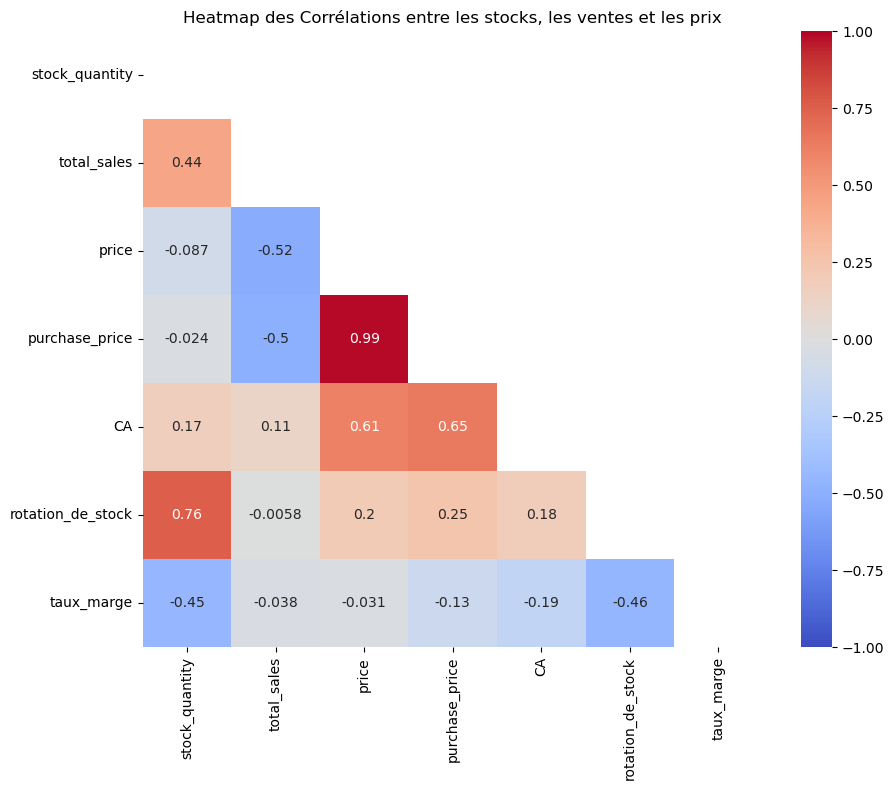

In [76]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

df_erp_liaison_web_map_correlation = df_erp_liaison_web[['stock_quantity', 'total_sales', 'price', 'purchase_price', 'CA', 'rotation_de_stock', 'taux_marge']].corr()


df_erp_liaison_web_demi_map_correlation = np.triu(df_erp_liaison_web_map_correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(data = df_erp_liaison_web_map_correlation, annot=True, cmap='coolwarm', center=0, mask=df_erp_liaison_web_demi_map_correlation, vmin=-1, vmax=1)
plt.title('Heatmap des Corrélations entre les stocks, les ventes et les prix')
plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
    Les variables corrélés sont les suivantes
</p>
<ul style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
    <li>Le prix de vente est fortement corrélé au prix d'achat</li>
    <li>La quantité de stock et fortement corrélé à la rotation de stock donc plus la quanité de stcok est elévé plus le produit à une rotation de stock élevée</li>
    <li>Le CA est moyennement corrélé aux prix de vente et d'achat donc ce sont les produits les plus chers qui générent le plus de CA</li>
    <li>Le nombre de vente est inversement moyennement corrélé avec les prix de vente et d'achat donc plus le produit est cher et plus il est acheté en petite quantité</li>
    <li>La quantité de stock est inversement moyennement corrélé avec le taux de marge donc les produits ayant beaucoup de stock ont une marge faible</li>
    <li>La quantité de stock est moyennement corrélé au nombre de vente donc la vente dépend des stocks disponible</li>
</ul>
</div>

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(51,165,182);">
    La gestion du prix de vente est excellente et permet d'avoir un bon taux de marge et un bon CA
    <br />
    Il faudrait améliorer la gestion des stocks et réduire les stocks des articles qui ont un CA faible et qui sont peu vendu
    <br />
</p>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [77]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_erp_liaison_web_taux_marge_positif.to_excel(excel_writer="Data_Bottleneck/Analyse_des_ventes.xlsx", sheet_name="sales_web_bottleneck", index=False)